In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('Penguin Species Prediction Dataset.csv')

## Inspecting

In [4]:
df = data.copy()

In [5]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

species               0
island                0
culmen_length_mm     10
culmen_depth_mm      10
flipper_length_mm    10
body_mass_g          10
sex                  10
dtype: int64

In [8]:
df.shape

(1000, 7)

## Cleaning

In [9]:
df['species'].unique()

<ArrowStringArray>
['Adelie', 'Gentoo', 'Chinstrap']
Length: 3, dtype: str

In [10]:
df['island'].unique()

<ArrowStringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str

In [11]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


In [12]:
## Outlier Function
def find_outlier(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    higher_limit = Q3 + 1.5 * IQR

    return lower_limit, higher_limit

In [13]:
clength = df['culmen_length_mm']
cdepth = df['culmen_depth_mm']
flength = df['flipper_length_mm']
bodymass = df['body_mass_g']

### Giving the columns variable names due to its length

In [14]:
clengthoutlier = find_outlier(df, 'culmen_length_mm')
print(clengthoutlier)

(np.float64(25.050000000000004), np.float64(62.24999999999999))


In [15]:
cllower_limit = 25.050000000000004
clhigher_limit = 62.24999999999999

for index, row in df.iterrows():
    if(row['culmen_length_mm'] < cllower_limit) or (row['culmen_length_mm'] > clhigher_limit):
        print(row)

In [16]:
clengthmean = clength.mean()
clengthmedian = clength.median()
print (clengthmean)
print (clengthmedian)

43.817777777777785
43.8


In [17]:
df['culmen_length_mm'] = clength.fillna(clengthmedian)

In [18]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      0
culmen_depth_mm      10
flipper_length_mm    10
body_mass_g          10
sex                  10
dtype: int64

In [19]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


In [20]:
cdepthoutlier = find_outlier(df, 'culmen_depth_mm')
print(cdepthoutlier)

(np.float64(11.450000000000003), np.float64(23.049999999999997))


In [21]:
cdepthlower_limit = 11.450000000000003
cdepthhigher_limit = 23.049999999999997

for index, row in df.iterrows():
    if (row['culmen_depth_mm'] < cdepthlower_limit) or (row['culmen_depth_mm'] > cdepthhigher_limit):
        print(row)

In [22]:
cdepthmean = cdepth.mean()
cdepthmedian = cdepth.median()

print(cdepthmean)
print(cdepthmedian)

17.335555555555555
17.8


In [23]:
df['culmen_depth_mm'] = cdepth.fillna(cdepthmedian)

In [24]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      0
culmen_depth_mm       0
flipper_length_mm    10
body_mass_g          10
sex                  10
dtype: int64

In [25]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


In [26]:
flengthoutlier = find_outlier(df, 'flipper_length_mm')
print(flengthoutlier)

(np.float64(154.5), np.float64(246.5))


In [27]:
flengthlower_limit = 154.5
flengthhigher_limit = 246.5

for index, row in df.iterrows():
    if (row['flipper_length_mm'] < flengthlower_limit) or (row['flipper_length_mm'] > flengthhigher_limit):
        print(row)

In [28]:
flengthmean = flength.mean()
flengthmedian = flength.median()
print(flengthmean)
print(flengthmedian)

199.22424242424242
195.0


In [29]:
df['flipper_length_mm'] = flength.fillna(flengthmedian)

In [30]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      0
culmen_depth_mm       0
flipper_length_mm     0
body_mass_g          10
sex                  10
dtype: int64

In [31]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


In [32]:
bodymassoutlier = find_outlier(df, 'body_mass_g')
print(bodymassoutlier)

(np.float64(2084.5), np.float64(6088.5))


In [33]:
bodymasslower_limit = 2084.5
bodymasshigher_limit = 6088.5

for index, row in df.iterrows():
    if (row['body_mass_g'] < bodymasslower_limit) or (row['body_mass_g'] > bodymasshigher_limit):
        print(row)

species              Gentoo
island               Biscoe
culmen_length_mm       43.3
culmen_depth_mm        13.7
flipper_length_mm     223.0
body_mass_g          6148.0
sex                  Female
Name: 74, dtype: object
species              Gentoo
island               Biscoe
culmen_length_mm       49.5
culmen_depth_mm        14.8
flipper_length_mm     223.0
body_mass_g          6114.0
sex                    Male
Name: 325, dtype: object
species              Gentoo
island               Biscoe
culmen_length_mm       48.3
culmen_depth_mm        14.0
flipper_length_mm     215.0
body_mass_g          6258.0
sex                  Female
Name: 395, dtype: object
species              Gentoo
island               Biscoe
culmen_length_mm       50.8
culmen_depth_mm        16.2
flipper_length_mm     216.0
body_mass_g          6176.0
sex                    Male
Name: 618, dtype: object
species              Gentoo
island               Biscoe
culmen_length_mm       50.3
culmen_depth_mm        14.7
flipp

### So here we have some outliers where it says these rows have values that don't correspond with the range of values in the body_mass_g column. 
### After research the average weight of a gentoo penguin is 4500g to 8500g so the values still fall under this range so we can conclude that the penguins are simply just overweight

In [34]:
bodymassmean = bodymass.mean()
bodymassmedian = bodymass.median()
df['body_mass_g'] = bodymass.fillna(bodymassmedian)

In [35]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      0
culmen_depth_mm       0
flipper_length_mm     0
body_mass_g           0
sex                  10
dtype: int64

In [36]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


In [37]:
df['sex'].value_counts()

sex
Male      528
Female    462
Name: count, dtype: int64

In [38]:
df['sex'] = df['sex'].fillna('Female')

In [39]:
df.isnull().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [40]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


In [41]:
df.to_csv('Cleaned Penguin Specie Dataset.csv', index = False)

## Visualizing

In [54]:
result = df.groupby('species')['island'].value_counts()

species    island   
Adelie     Dream        276
           Torgersen    171
           Biscoe        14
Chinstrap  Dream        251
Gentoo     Biscoe       288
Name: count, dtype: int64

In [56]:
results = result.unstack()

island,Biscoe,Dream,Torgersen
species,,,
Adelie,14.0,276.0,171.0
Chinstrap,NaN,251.0,NaN
Gentoo,288.0,NaN,NaN


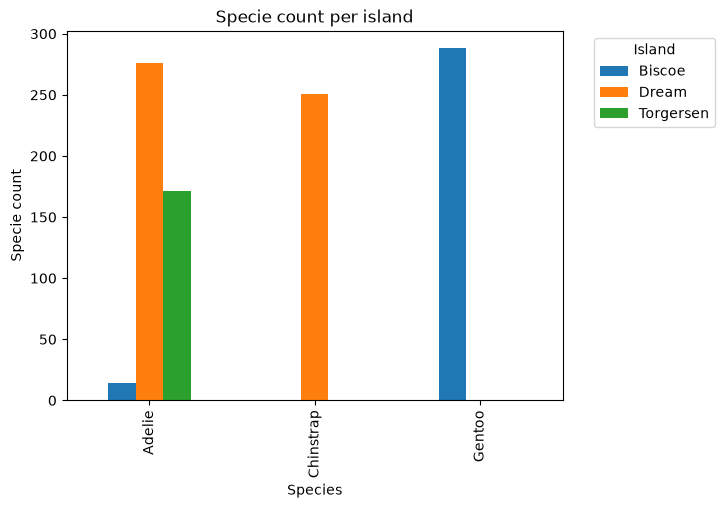

In [58]:
results.plot(kind = 'bar')

plt.xlabel('Species')
plt.ylabel('Specie count')
plt.title('Specie count per island')
plt.legend(title = 'Island', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

## This chart shows that the *Adeile* specie is the only specie of penguin that can be found on all three island with Biscoe island being the least populated and Dream island being the most populated island with the Adeile specie.

## The 'Chinstrap' specie can only be found on Dream island.
## And the Gentoo specie can only be found on the Biscoe island which has the most amount of penguin on any island.

In [59]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male
